## Mission 4 - Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

**Step 1: Tasks 1.1 - 1.4 Completed by Regan Yates**

In [1]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [2]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
from io import BytesIO

blob_service_client = BlobServiceClient.from_connection_string(connect_str)

blob_client = blob_service_client.get_blob_client(
    container = container_name,
    blob = blob_name
)
blob_data = blob_client.download_blob().readall()

df_house_price = pd.read_csv(BytesIO(blob_data))

df_house_price


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,48,8.297631,5.935734,602134.8167
1,287.678577,1,2,1,37,6.061466,10.827392,591425.1354
2,232.998485,1,3,2,14,2.911442,6.904599,464478.6969
3,199.664621,5,2,2,17,2.070949,8.284019,583105.6560
4,89.004660,4,3,3,34,1.523278,14.648277,619879.1425
...,...,...,...,...,...,...,...,...
495,138.338057,2,2,2,16,4.296086,5.562583,488496.3507
496,195.914028,2,3,1,45,7.406261,2.845105,657736.9217
497,69.433659,1,1,2,18,8.629724,6.263264,405324.9502
498,293.598702,5,1,3,41,5.318891,16.990684,773035.9680


In [3]:
df_house_price.head()


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,48,8.297631,5.935734,602134.8167
1,287.678577,1,2,1,37,6.061466,10.827392,591425.1354
2,232.998485,1,3,2,14,2.911442,6.904599,464478.6969
3,199.664621,5,2,2,17,2.070949,8.284019,583105.6560
4,89.004660,4,3,3,34,1.523278,14.648277,619879.1425


In [4]:
df_house_price.dtypes

Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object

In [5]:
df_house_price.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

Task 2.5. Write 1–2 sentences explaining the insights from each visualisation.

**Step 2: Tasks 2.1 - 2.5 Completed by Zaynah Ali**

## Step 2: Exploratory Data Analysis (EDA)

### Task 2.1: Summary Statistics

The summary statistics provide an overview of the numerical variables in the house price dataset.

In [6]:
df_house_price.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


Insight: The dataset contains 500 house records. House sizes range from approximately 51 to 298 square feet, with an average size of about 175 square feet. Most houses have around 3 bedrooms and 2 bathrooms.

Task 2.2: Relationship Between Square Feet and Price

A scatter plot is used to visualise the relationship between the size of a house and its price.

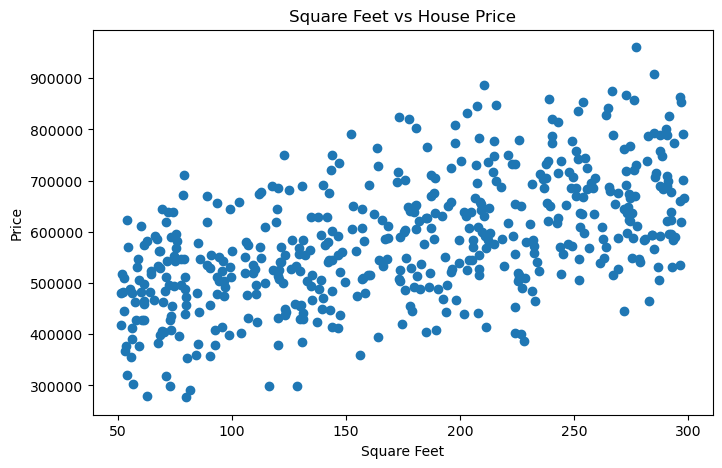

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_house_price['Square_Feet'], df_house_price['Price'])

plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.title('Square Feet vs House Price')

plt.show()

Insight:The scatter plot shows a positive relationship between Square Feet and Price. In general, larger houses tend to have higher prices.

Task 2.3: Distribution of House Prices

A histogram is used to show the distribution of house prices in the dataset.

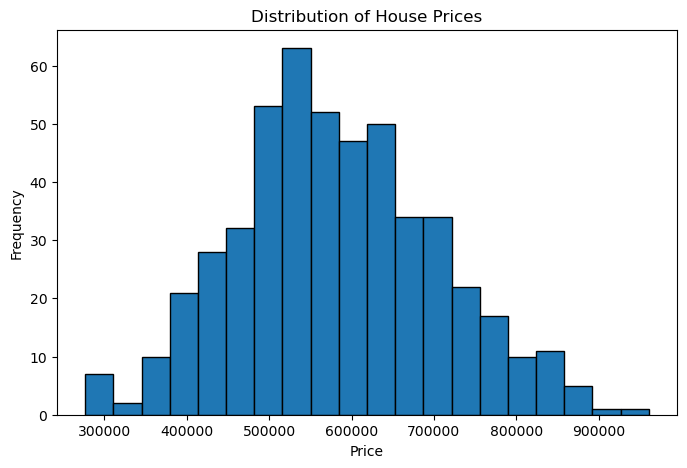

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df_house_price['Price'], bins=20, edgecolor='black')

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.show()

Insight:Most of the house prices are between  $500,000 and $700,000. There are fewer houses at the lower and higher price ranges.

Task 2.4: Correlation Matrix

The correlation matrix is used to show the strength and direction of the relationships between the numerical features in the dataset.

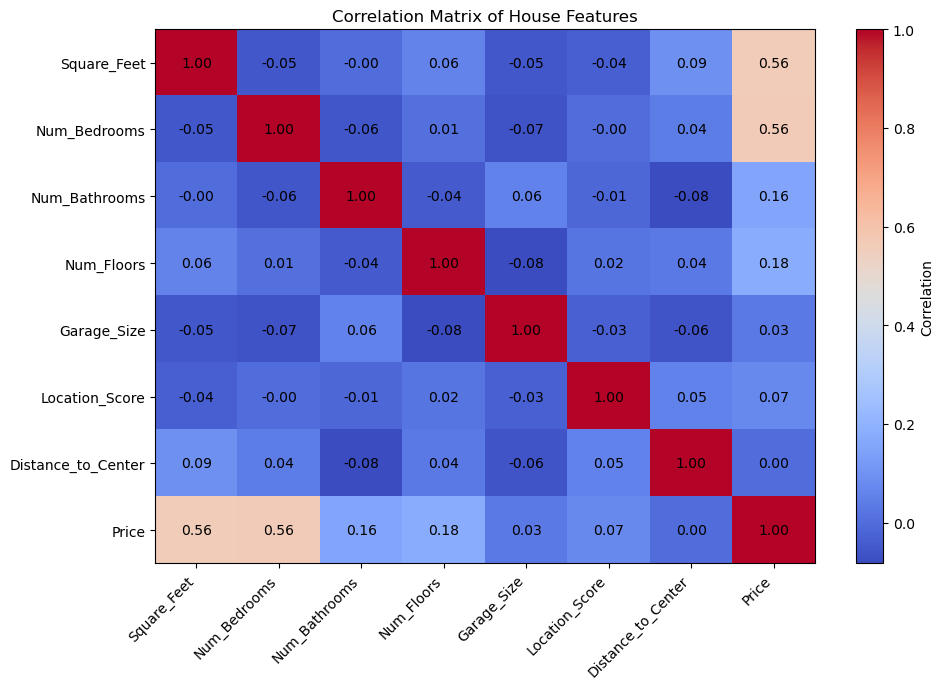

In [9]:
import matplotlib.pyplot as plt

correlation_matrix = df_house_price.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of House Features')
plt.tight_layout()
plt.show()

Insight: Square Feet and Number of Bedrooms have the strongest positive correlation with Price, both at 0.56. The other features have weaker relationships with Price.

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

Task 3.6. Write 1–2 sentences explaining the insights from the visualisation.

**Step 3: Tasks 3.1 - 3.6 Completed by Christina Gilmour**

In [10]:
# Import Libraries

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

**Task 3: Import Library Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings  
- Task 2: Simple Linear Regression with Train-Test Split. 
- Code Block # 1: lines 1 - 5

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

In [11]:
# Task 3.1: Split the Data into Features and Target Split the dataset into features (X) and target variable (y).

# Define Independent feature variables (x) and target variable (y): 'Price' 
x_multi = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors','Garage_Size', 'Location_Score', 'Distance_to_Center']] # Independent features variables (x) 
y = df_house_price['Price'] # Dependent Target variable (y)

**Task 3.1 Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings 
- Task 3: Multiple Linear Regression with Train-Test Split. 
- Code Block # 1: # Define independent variables (Age and YearsExperience) - lines 1 - 2

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

In [12]:
# Task 3.2: Split the Data into Training and Testing Sets Split the data into training (80%) and testing (20%) sets.

# Split the data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x_multi, y, test_size=0.2, random_state=42) # test_size=0.2: testing 20%. Remaining 80% for training

# Display x_train Top 5: Output verification 
display(x_train.head())

**Task 3.2 Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings  
- Task 3: Multiple Linear Regression with Train-Test Split. 
- Code Block # 1: # Split the data into 80% training and 20% testing - lines 4 - 5

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

In [13]:
# Task 3.3: Train the Multiple Linear Regression (MLR) model using the training data.

model = LinearRegression()

# Fit the model on the training data
model.fit(x_train, y_train)

🏃 View run serene_kettle_3hjd2kt3 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/99afb189-04f1-4d8c-889d-efa68d186eae/#/experiments/055b971f-92ab-4f9c-bde9-8f63b417b413/runs/a38232c3-7ace-4818-b4cc-3ccf6386a823
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/99afb189-04f1-4d8c-889d-efa68d186eae/#/experiments/055b971f-92ab-4f9c-bde9-8f63b417b413


LinearRegression()

**Task 3.3 Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings  
- Task 2: Simple Linear Regression with Train-Test Split. 
- Code Block #2: # Fit the model on the training data - lines 1 - 5 

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

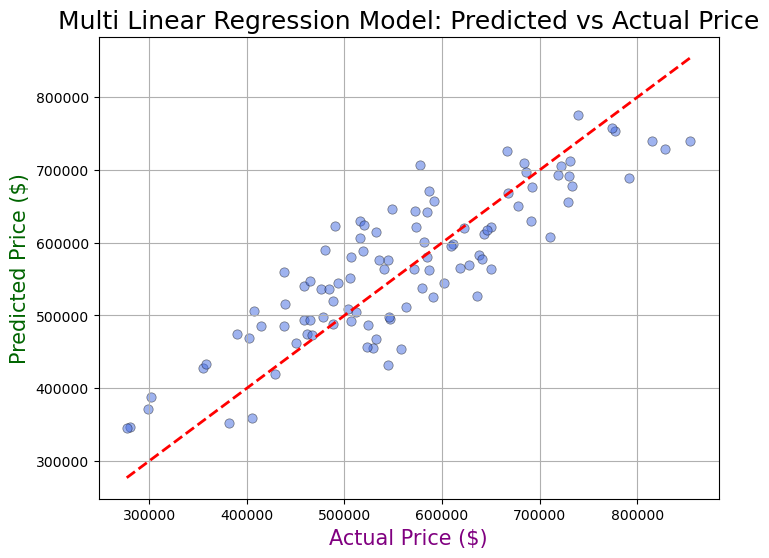

In [14]:
# Task 3.4: Visualise the Predicted vs Actual Prices Create a scatter plot comparing the actual prices and predicted prices for the test set.

# Predict House 'Price' on the test set
y_pred = model.predict(x_test) # x_test = Feature variables (Uses Multiple Features to Predict 'Price')

# Create Scatter plot comparing Actual Price vs Predicted Price 
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.5, s=45, edgecolors='black', linewidths=0.5) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Target Line (y=x)') # Target Line (Reference Point): Predicted Price = Actual Price
plt.grid(True)
plt.title('Multi Linear Regression Model: Predicted vs Actual Price', color='black', fontsize=18)
plt.xlabel('Actual Price ($)', color='purple', fontsize='15')
plt.ylabel('Predicted Price ($)', color='darkgreen', fontsize='15')
plt.show()

**Task 3.4: Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings  
- Task 3: Multiple Linear Regression with Train-Test Split. 
- Code Block #1: # Predict Salary on the test set - lines 11 - 12 
- Task 2: Simple Linear Regression with Train-Test Split. 
- Code Block #2 # Plot the regression line lines - 10 - 16

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

**Task 3.4: Target Line Code Source: w3 school website**

_Some of the dots overlap which caused them to blend together so I increased the scatterplot size and made the dots transparent to separate them visually._

- https://www.w3schools.com/python/matplotlib_plotting.asp - _Target Line axis marker points_
- https://www.w3schools.com/python/matplotlib_scatter.asp - _Dot transparency_
- https://www.w3schools.com/python/matplotlib_line.asp - _Dash line style_
- https://www.w3schools.com/python/pandas/ref_df_min.asp - Return min value   
- https://www.w3schools.com/python/pandas/ref_df_max.asp - Return max value

**Thought Process**: Added a target line (reference point) between the actual vs predicted prices to make it easier to interpret. It serves as a visual marker to show which houses have been under predicted, over predicted or accurate/close based on their proximity to the line. I added the same target line to the RFR model to allow consistent visual comparison between both models for Step 5 and shared a brief explanation with my group of how this can be used as a reference point to improve our interpretation and analysis of the results as follows: 

- Above the line = Over predicted. 
- Under the line = Under predicted. 
- On or near the line = Accurate or Closely predicted      


In [15]:
# Task 3.5 (PART 1): Evaluate the Model using Root Mean Squared Error (RMSE) and interpret the results.

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Multiple Linear Regression RMSE: {rmse_multi}')

Multiple Linear Regression RMSE: 63952.37599755184


**Task 3.5 (PART 2): Interpret Root Mean Squared Error (RMSE) results.**

**Interpretation**: The MLR model's RMSE results returned a prediction error of **$63,952.38**, showing the overall difference between Actual and Predicted house prices.

**Task 3.5 Code Source**: 
- Week 5: Predictive Modeling and Clustering notebook & Thinkific recordings  
- Task 3: Multiple Linear Regression with Train-Test Split. 
- Code Block #2: # Evaluate model performance - lines 1 - 4   

https://app.fabric.microsoft.com/groups/4c103e55-88b3-4943-b70c-ce1a81d42049/synapsenotebooks/2d167360-b8d3-4c98-b095-a9cfe636e3dc?experience=fabric-developer

**Task 3.6. Write 1–2 sentences explaining the insights from the visualization.**

**Insight**: The MLR results show that the model over predicted lower end market house prices however, greatly under predicted higher end housing prices suggesting that the features (variables) may not provide a complete realistic picture alone and there could be other contributing factors that influence the models overall accuracy. Examples could include the following:

- Year Built: Newer higher end build vs Older lower end house  
- Pre-existing Condition
- Property Type: House, Apartment
- Parking: On Street, Off Street
- School Zoning  
- Land Area: Garden, Backyard, Courtyard
- Bedroom Size 

**Thought Process**: As a first home buyer in 2015, these were important features I personally looked for when searching the competitive housing market to purchase my first home.

**Disclaimer**: All insights and explanations are my own. I have referenced all code sources including the Week 5 fabric notebook that follows along the tutors instructions from the Thinkific recordings. 

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

**Step 4: Tasks 4.1 - 4.3 Completed by Regan Yates**

In [16]:
x_train
x_test
y_train
y_test

361    591058.7089
73     667693.0003
374    532377.5802
155    478489.2990
104    730197.4806
          ...     
347    464849.9178
86     572360.6499
75     557752.8374
438    649930.0523
15     523527.9747
Name: Price, Length: 100, dtype: float64

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(random_state = 42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

rmse_rf

🏃 View run elated_shirt_29tq89cd at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/99afb189-04f1-4d8c-889d-efa68d186eae/#/experiments/055b971f-92ab-4f9c-bde9-8f63b417b413/runs/49e8e9df-2126-4891-8847-f0df86bd052b
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/99afb189-04f1-4d8c-889d-efa68d186eae/#/experiments/055b971f-92ab-4f9c-bde9-8f63b417b413


71733.35944826744

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

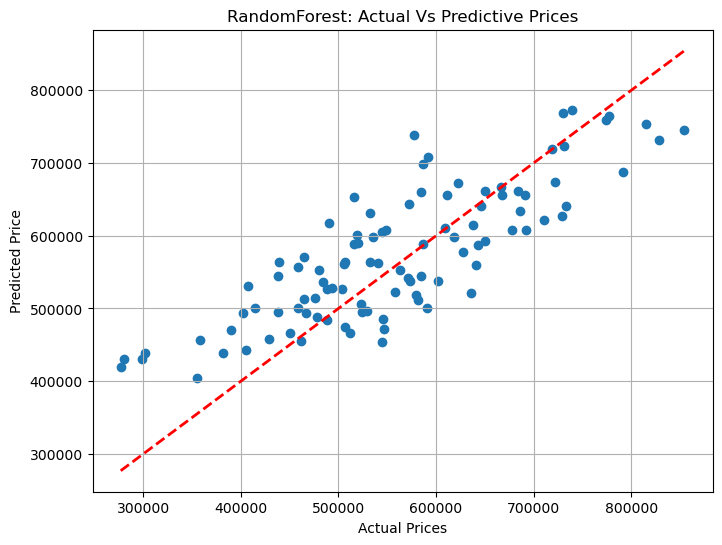

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)    
plt.xlabel("Actual Prices")        
plt.ylabel("Predicted Price")   
plt .title("RandomForest: Actual Vs Predictive Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Target Line (y=x)') # Target Line (Reference Point): Predicted Price = Actual Price  
plt.grid(True)
plt.show()

Insight: the MLR model performed better based on RMSE, with an RMSE of $64k compared with $71K for the Random Forest model. Tha suggest MLRs predictions were closer to the actual house prices on the test data

## Step 5: Conclusion and Insights


##### <u>Task 5.1: Insights and Recommendations</u>
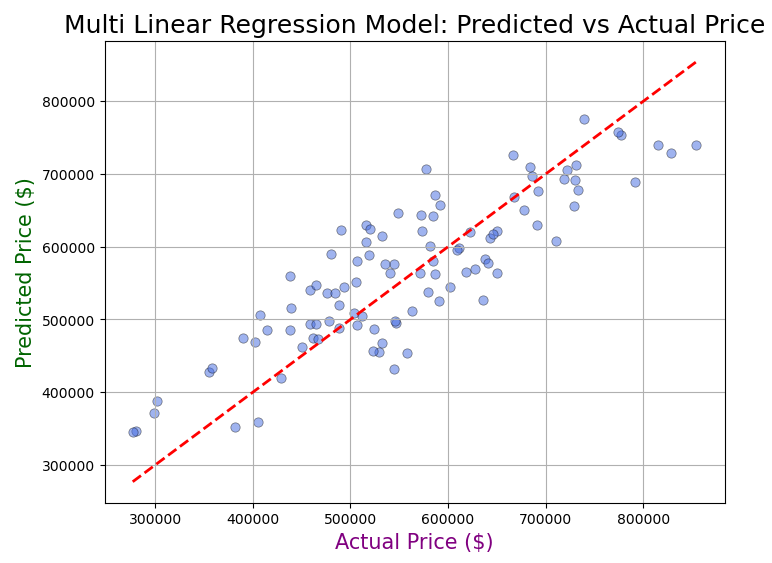
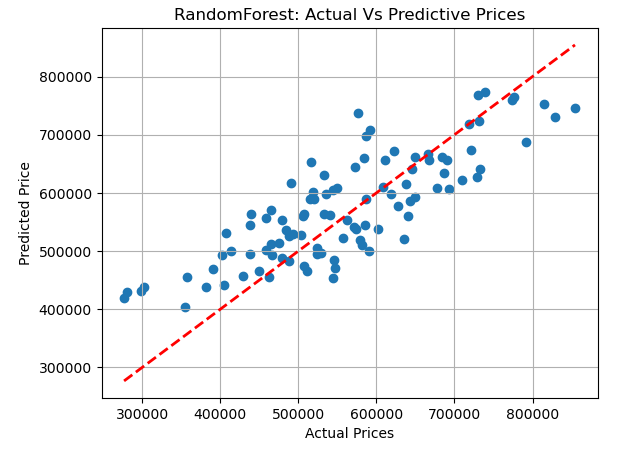
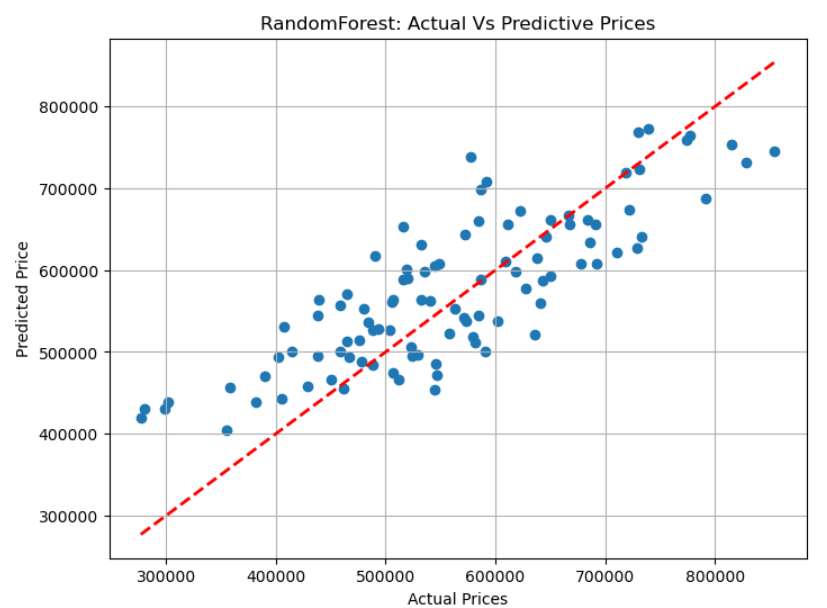
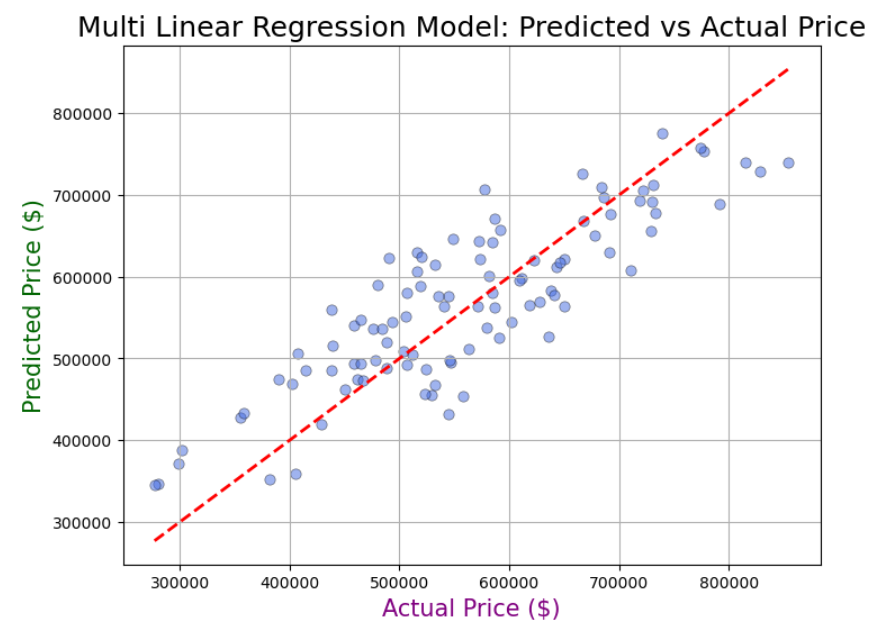

**Q1: Part 1 - Completed by Christina Gilmour**

    Q1: Part 1. Based on the RMSE and visualisations, summarise which model performs better.

Based on the RMSE and visualizations for both the MLR and RFR models, the **Multi Linear Regression Model** (MLR) **performs better over all with a lower RMSE of **$63,952**.38** compared to the **higher** **Random Forest Regressor Model** (RFR) of **$71,733.36** a total difference of **$7,780.98**.

When comparing the MLR and RFR scatter plot visualizations, **the RFR shows a higher margin of error at the lower market end** where actual house prices in the **$250K** range were **over predicted** to approx. **$420K to $430K** (approx. **$180K** difference). **In the mid market range**, actual house prices between **$560K to $590K** were also **over predicted** closer to **$700K to $730K** (approx. **$140K** difference) contributing to the RFR's higher overall RMSE. 

In direct comparison, the MLR model also **over predicted lower end** house prices but with a **smaller margin of error**. Actual house prices around **$250K** were predicted closer to **350K** (approx. **$100K**). **In the same mid market range**, actual prices of around **$580K to $590K** were **over predicted** around **$660-700K** (approx. **$80K - $110K** difference), clearly showing the MLR model performed better overall. 

Both models visualizations show an even spread of under predictions at the higher market end which leans towards the RFR higher RMSE being the result of greater over predictions at the lower market end. 


**Q1: Part 2 - Completed by Regan Yates**

    Q1: Part 2. Why does the MLR model perform better?

MLR looked at the house features and calculated a linear mathematical relationship between them and price.

While the Random Forest used many decision trees combined.

Same goal predict price

The two models used the same type of house information but MLR modelled the relationship using a linear equation, while Random Forest used multiple decision trees, in our result, the linear equation approach produced the lower prediction error..

MLR = $63,952.38
Random Forest = $71,733.36

**Q2 - Completed by Zaynah Ali**

    Q2. Discuss any improvements that could be made to both models.

Both models could be improved by using more data and including other information that could affect house prices, such as the location, age of the house, land size and condition of the property.

For the MLR model, we could check for any unusual values or outliers that may be affecting the predictions. We could also check which house features are actually useful for predicting the price and remove any that are not helping the model.

For the Random Forest model, we could adjust settings such as the number of trees and how deep the trees can grow. Testing different settings could help improve the model and lower its prediction error.

We could also use cross-validation for both models. This would test the models on different parts of the data and give us a better idea of how well they would perform on new house data.

These improvements may help reduce some of the over-predictions we saw in the lower and middle price ranges and make both models more accurate



# **Mission 4: Completed by Group 3**

1. **Christina Gilmour**: 
    - Completed Step 3 (All Tasks) 
    - Task 5.1 (Q1: Part 1): Based on the RMSE and visualisations, summarise which model performs better. 
2. **Regan Yates**: 
    - Completed Step 1 and Step 4 (All Tasks)  
    - Task 5.1 (Q1: Part 2): Why does the MLR model perform better?
3. **Zaynah Ali**: 
    - Completed Step 2 (All Tasks) 
    - Task 5.1 (Q2): Discuss any improvements that could be made to both models.


**Teams Group Chat**: Group 3 - Mission 4 Chat 
- https://teams.microsoft.com/l/chat/19:9321d8f17d624cf89167118a61e1fdf1@thread.v2/conversations?context=%7B%22contextType%22%3A%22chat%22%7D

**Teams Meetings**

1. **Meeting 1**: _**Intro to Mission 4 & Planning**_
    - **Date**: Tuesday 2st September
    - **Time**: 6PM - 6:30PM
    - **Agenda**: Assignment of Steps 1-4, Loop Task Tracker, Schedule next meeting.
    - **Attendance**: Christina, Regan & Zaynah
2. **Meeting 2**: _**1 week task follow-up & Check in**_
    - **Date**: Tuesday 8th September
    - **Time**: 6PM - 6:30PM
    - **Agenda**: Steps 2-4 update. Share Step 5 task ideas and insights as we tidy up and complete assigned Steps 2 - 4. Schedule next meeting.
    - **Attendance**: Christina, Regan & Zaynah
3. **Meeting 3**: _**Step 5 follow up**_ 
    - **Date**: Thursday 10th September
    - **Time**: 6PM - 6:30PM
    - **Agenda**: Decision to split Step 5 up between 3 of us and aim to complete our parts by Monday submission. 
    - **Attendance**: Christina & Regan
    - **Absent**: Zaynah (family emergency) communicated via group chat and shared decision changes and updates.

**Teams Loop Kanban**: Group 3: Mission 4 Task Tracker 
- [https://mreadyhq-my.sharepoint.com/:fl:/g/personal/christinag_missionreadyhq_com/IQD6aG5KNhDlTKubCFXW9IEgAbfP_ir8MNFELlrIOeEru9Y?nav=cz0lMkZwZXJzb25hbCUyRmNocmlzdGluYWdfbWlzc2lvbnJlYWR5aHFfY29tJmQ9YiEwT2tFQjViMDBFR3hZS3lmcG9tYXBqbmlPamlqRXA5R3ZvUy1TZGhhSHpfOVY1RENsSF9FVHBMeWJfTnpreVdWJmY9MDFYWVJPS1g3Mk5CWEVVTlFRNFZHS1hHWUlLWExQSkFKQSZjPSUyRiZmbHVpZD0xJmE9VGVhbXMmcD0lNDBmbHVpZHglMkZsb29wLXBhZ2UtY29udGFpbmVy](link-URL)
